<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 9.1: NN with Keras
INSTRUCTIONS:
- Read the guides and hints, then create the necessary analysis and code to find an answer and conclusion for the task below.
- **NOTE**: This is a Regression problem. Consider the appropriate:
    - Activation function
    - Loss/Cost Function
    - Metrics

### Import libraries

In [13]:
# !pip install tensorflow

In [1]:
# insert code here
# Import the library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Sequential

### Load data
Load the Diabetes dataset from **SciKit-Learn**.

In [3]:
# insert code here
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [5]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### Prepare input data

In [7]:
# insert code here
X = diabetes.data
y = diabetes.target
n_cols = X.shape[1]

### Split the data (training/test)

In [10]:
# insert code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

### Create the model's architecture

In [13]:
# insert code here
model = Sequential()

In [15]:
# insert code here
model.add(Input(shape=(n_cols,)))
model.add(Dense(15, activation = 'relu'))
model.add(Dense(5, activation = 'relu'))
model.add(Dense(1, activation = 'linear'))

In [17]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 15)                  │             165 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               6 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 251 (1004.00 B)

 Trainable params: 251 (1004.00 B)

 Non-trainable params: 0 (0.00 B)

None


### Compile the model

In [20]:
# insert code here
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mse']
)

### Fit the training data

In [23]:
%%time
# insert code here
from sklearn.utils import shuffle
X_train2, y_train2 = shuffle(X_train, y_train)

CPU times: total: 0 ns
Wall time: 0 ns


In [25]:
mod = model.fit(
    X_train2, 
    y_train2,
    validation_split = 0.25,
    batch_size = 10,
    epochs = 100,
    verbose = 1
) # History object assigned to mod.

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 30035.4805 - mse: 30035.4805 - val_loss: 29160.0254 - val_mse: 29160.0254
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29995.0996 - mse: 29995.0996 - val_loss: 29111.9004 - val_mse: 29111.9004
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29939.6387 - mse: 29939.6387 - val_loss: 29046.3906 - val_mse: 29046.3906
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29862.4238 - mse: 29862.4238 - val_loss: 28956.5254 - val_mse: 28956.5254
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29756.0391 - mse: 29756.0391 - val_loss: 28836.2539 - val_mse: 28836.2539
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29616.7324 - mse: 29616.7324 - val_loss: 28682.3438 - val_mse: 28682.3438
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29440.5332 - mse: 29440.5332 - val_loss: 28490.2988 - val_mse: 28490.2988
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29221.535

### Create predictions

In [27]:
# insert code here
predictions = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


### Evaluate the model

In [29]:
# insert code here
score = model.evaluate(X_test, y_test)
print(score[0])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3096.1189 - mse: 3096.1189 
3096.118896484375


### Visualisation of cost

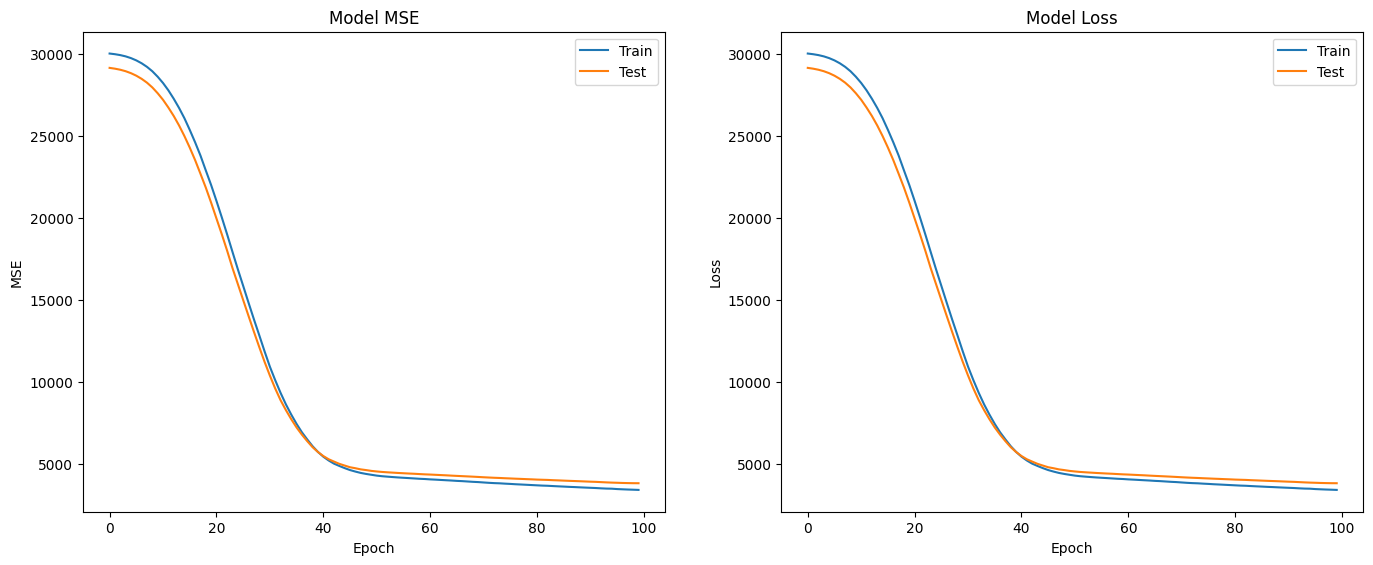

In [31]:
# insert code here
fig, ax = plt.subplots(1,2, figsize = (16,6))
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

ax[0].plot(mod.history['mse'], label='Train')
ax[0].plot(mod.history['val_mse'], label ='Test')
ax[0].set_title('Model MSE')
ax[0].set_ylabel('MSE')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(mod.history['loss'], label='Train')
ax[1].plot(mod.history['val_loss'], label ='Test')
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.show()

### Visualisation of residuals

In [35]:
# insert code here
r2 = r2_score(y_test, predictions)
n, p = X.shape

adj_r2 = 1 - (1-r2) * ((n-1)/(n-p-1))

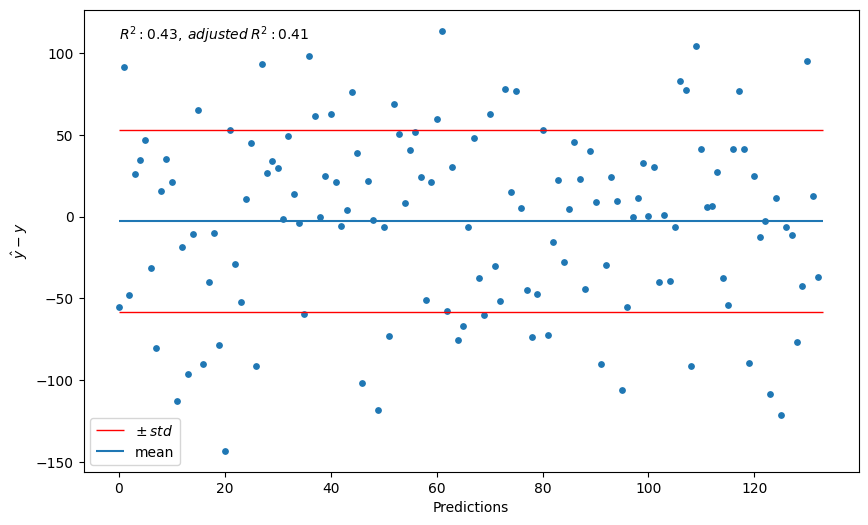

In [39]:
difference = predictions.flatten() - y_test
d_mean = difference.mean()
d_std = difference.std()
n_pred = len(predictions)
plt.figure(figsize = (10,6))
plt.scatter(range(n_pred), difference, s =15)
plt.hlines(d_mean + d_std, 0, n_pred, 'r', lw=1, label = '$\pm \: std$')
plt.hlines(d_mean, 0, n_pred, label = 'mean')
plt.hlines(d_mean - d_std, 0 , n_pred, 'r', lw =1)
plt.xlabel('Predictions')
plt.ylabel('$\hat y - y$')
plt.legend()
plt.text(0, difference.max()*0.95, '$R^2: %.2f, \: adjusted \: R^2: %.2f$' %(r2, adj_r2))
plt.show()
           



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



